# I. Data exploration

Đường dẫn dataset được tìm thấy: /kaggle/input/datasets/ipythonx/mvtec-ad/transistor

=== THỐNG KÊ SỐ LƯỢNG MẪU ===
Split     Category  Count  Has Mask
Train         good    213     False
 Test     cut_lead     10      True
 Test         good     60     False
 Test    misplaced     10      True
 Test    bent_lead     10      True
 Test damaged_case     10      True


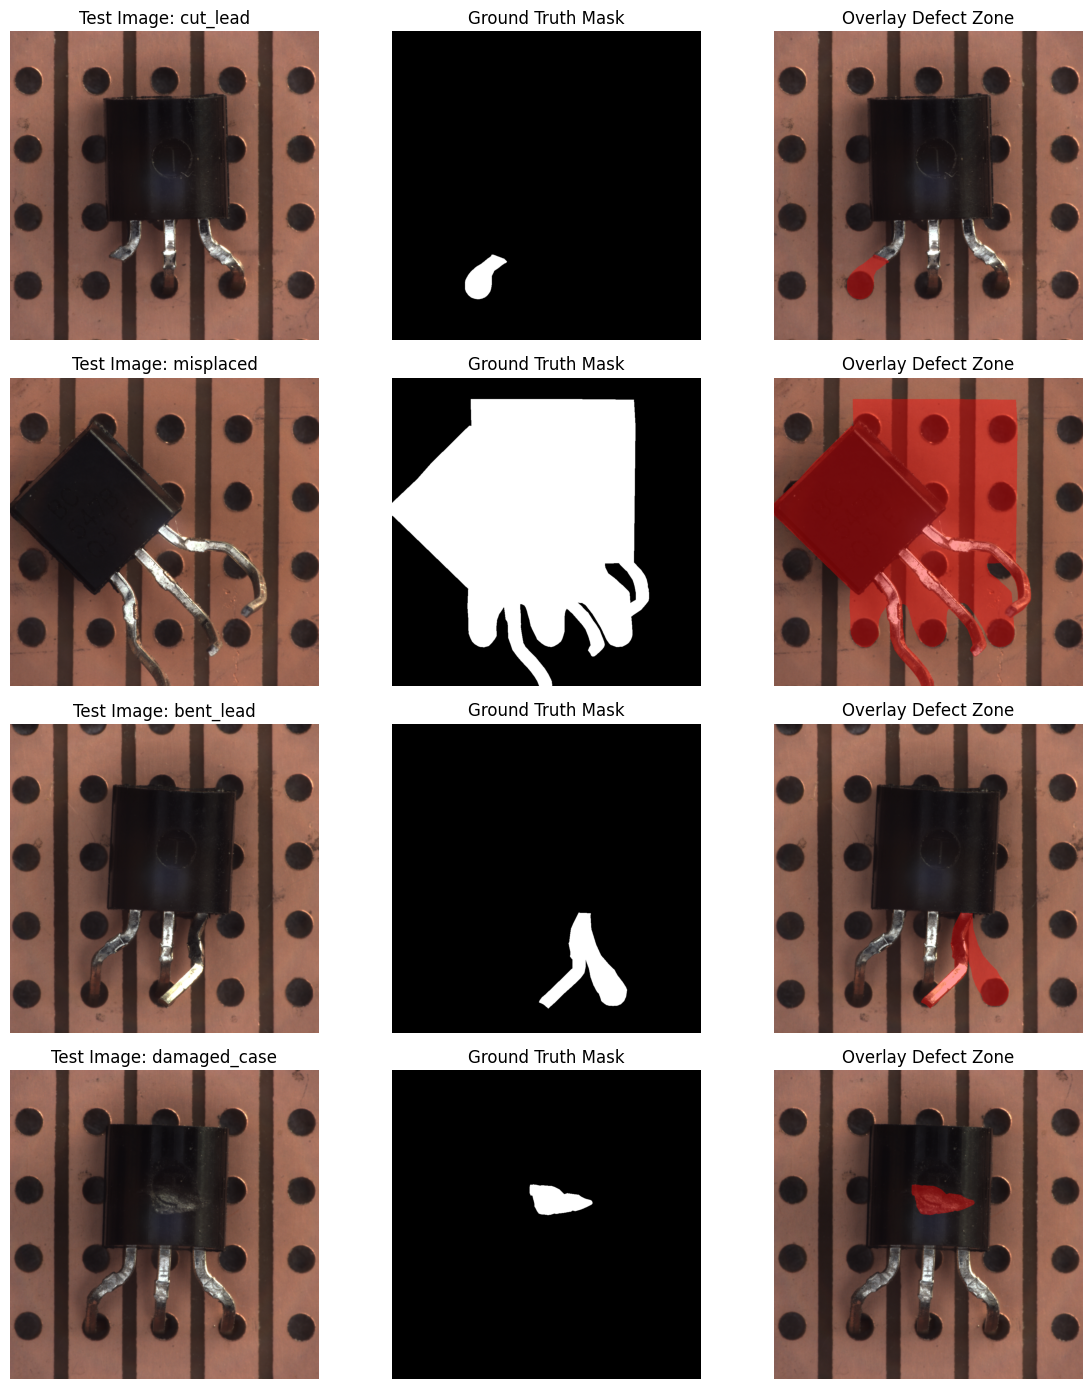

In [15]:
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

dataset_path = Path("/kaggle/input/datasets/ipythonx/mvtec-ad/transistor")
print(f"Đường dẫn dataset được tìm thấy: {dataset_path}")

data_summary = []

train_good_path = dataset_path / "train" / "good"
if train_good_path.exists():
    num_train_good = len(list(train_good_path.glob("*.png")))
    data_summary.append(
        {
            "Split": "Train",
            "Category": "good",
            "Count": num_train_good,
            "Has Mask": False,
        }
    )

# Test & Ground Truth
test_path = dataset_path / "test"
gt_path = dataset_path / "ground_truth"

if test_path.exists():
    for category_dir in test_path.iterdir():
        if category_dir.is_dir():
            category_name = category_dir.name
            num_images = len(list(category_dir.glob("*.png")))
            has_gt = (
                (gt_path / category_name).exists()
                if category_name != "good"
                else False
            )
            data_summary.append(
                {
                    "Split": "Test",
                    "Category": category_name,
                    "Count": num_images,
                    "Has Mask": has_gt,
                }
            )

df_summary = pd.DataFrame(data_summary)
print("\n=== THỐNG KÊ SỐ LƯỢNG MẪU ===")
print(df_summary.to_string(index=False))

# 3. TRỰC QUAN HÓA LỖI VÀ MASK
defect_types = [
    d.name for d in test_path.iterdir() if d.is_dir() and d.name != "good"
]

fig, axes = plt.subplots(
    len(defect_types), 3, figsize=(12, 3.5 * len(defect_types))
)
if len(defect_types) == 1:
    axes = np.expand_dims(axes, axis=0)

for idx, defect in enumerate(defect_types):
    test_img_p = list((test_path / defect).glob("*.png"))[0]

    # Kiểm tra quy cách đặt tên mask trên Kaggle
    gt_mask_p = gt_path / defect / (test_img_p.stem + "_mask.png")
    if not gt_mask_p.exists():
        gt_mask_p = gt_path / defect / test_img_p.name

    img = cv2.cvtColor(cv2.imread(str(test_img_p)), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(gt_mask_p), cv2.IMREAD_GRAYSCALE)

    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"Test Image: {defect}")
    axes[idx, 0].axis("off")

    axes[idx, 1].imshow(mask, cmap="gray")
    axes[idx, 1].set_title("Ground Truth Mask")
    axes[idx, 1].axis("off")

    overlay = img.copy()
    overlay[mask > 0] = [255, 0, 0]
    blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

    axes[idx, 2].imshow(blended)
    axes[idx, 2].set_title("Overlay Defect Zone")
    axes[idx, 2].axis("off")

plt.tight_layout()
plt.show()

# II. Preprocessing

In [16]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# 1. ĐƯỜNG DẪN DỮ LIỆU
dataset_path = Path("/kaggle/input/datasets/ipythonx/mvtec-ad/transistor")

# 2. ĐỊNH NGHĨA TRANSFORMS (Chuẩn ImageNet)
# Kích thước 224x224 bảo toàn đủ nét cho chân linh kiện (cut_lead, bent_lead)
IMAGE_SIZE = (224, 224)

train_transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),
    ]
)

# Resize mask bằng NEAREST để giữ nguyên giá trị nhị phân (0 hoặc 1)
mask_transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.NEAREST),
        transforms.ToTensor(),
    ]
)


# 3. PYTORCH DATASET CLASS
class MVTecTransistorDataset(Dataset):

    def __init__(self, root_dir, split="train", transform=None, mask_transform=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transform = transform
        self.mask_transform = mask_transform

        self.image_paths = []
        self.mask_paths = []
        self.labels = []  # 0: Good, 1: Anomaly
        self.categories = []

        if self.split == "train":
            train_dir = self.root_dir / "train" / "good"
            for img_p in sorted(train_dir.glob("*.png")):
                self.image_paths.append(img_p)
                self.mask_paths.append(None)
                self.labels.append(0)
                self.categories.append("good")

        elif self.split == "test":
            test_dir = self.root_dir / "test"
            gt_dir = self.root_dir / "ground_truth"

            for category_dir in sorted(test_dir.iterdir()):
                if category_dir.is_dir():
                    cat_name = category_dir.name
                    is_anomaly = 0 if cat_name == "good" else 1

                    for img_p in sorted(category_dir.glob("*.png")):
                        self.image_paths.append(img_p)
                        self.labels.append(is_anomaly)
                        self.categories.append(cat_name)

                        if is_anomaly:
                            mask_p = gt_dir / cat_name / (img_p.stem + "_mask.png")
                            if not mask_p.exists():
                                mask_p = gt_dir / cat_name / img_p.name
                            self.mask_paths.append(mask_p)
                        else:
                            self.mask_paths.append(None)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        category = self.categories[idx]

        if self.transform:
            image = self.transform(image)

        # Xử lý Mask
        if self.split == "test":
            mask_path = self.mask_paths[idx]
            if mask_path and mask_path.exists():
                mask = Image.open(mask_path).convert("L")
            else:
                # Tạo mask đen cho ảnh good
                mask = Image.fromarray(
                    np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1]), dtype=np.uint8)
                )

            if self.mask_transform:
                mask = self.mask_transform(mask)
                mask = (mask > 0.5).float()  # Binarize mask thành 0.0 và 1.0

            return image, label, mask, category

        return image, label


# 4. KHOI TAO DATALOADER
train_dataset = MVTecTransistorDataset(
    dataset_path, split="train", transform=train_transform
)
test_dataset = MVTecTransistorDataset(
    dataset_path,
    split="test",
    transform=test_transform,
    mask_transform=mask_transform,
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"✅ Khởi tạo DataLoader thành công!")
print(f"• Train batches: {len(train_loader)} (Tổng: {len(train_dataset)} ảnh)")
print(f"• Test batches: {len(test_loader)} (Tổng: {len(test_dataset)} ảnh)")

✅ Khởi tạo DataLoader thành công!
• Train batches: 14 (Tổng: 213 ảnh)
• Test batches: 7 (Tổng: 100 ảnh)


# III. Model Selection & Implementation

In [17]:
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

# 1. ĐỊNH NGHĨA MÔ HÌNH PADIM (Feature Extractor + Distance Model)
class PaDiM:
    def __init__(self, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.device = device
        # Dùng ResNet18 pretrained làm Feature Extractor
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT).to(self.device)
        self.backbone.eval()
        
        # Đóng băng gradient
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Đăng ký Hook để trích xuất Feature Map từ layer1, layer2, layer3
        self.outputs = []
        def hook(module, input, output):
            self.outputs.append(output)
            
        self.backbone.layer1.register_forward_hook(hook)
        self.backbone.layer2.register_forward_hook(hook)
        self.backbone.layer3.register_forward_hook(hook)
        
        self.mean = None
        self.cov = None
        self.idx = None

    def extract_features(self, x):
        self.outputs = []
        _ = self.backbone(x)
        
        # Resize các feature maps về cùng kích thước của layer1
        target_size = self.outputs[0].shape[-2:]
        features = []
        for out in self.outputs:
            features.append(F.interpolate(out, size=target_size, mode='bilinear', align_corners=False))
            
        # Concatenate theo kênh (Channels)
        return torch.cat(features, dim=1)

    def fit(self, train_loader):
        print("🚀 Đang trích xuất đặc trưng (Feature Extraction) từ tập Train...")
        feature_list = []
        
        with torch.no_grad():
            for imgs, _ in tqdm(train_loader):
                imgs = imgs.to(self.device)
                feats = self.extract_features(imgs)
                feature_list.append(feats.cpu())
                
        # [N, C, H, W]
        features = torch.cat(feature_list, dim=0)
        N, C, H, W = features.shape
        
        # Chọn ngẫu nhiên 100 kênh đặc trưng để tối ưu bộ nhớ
        torch.manual_seed(1024)
        self.idx = torch.randperm(C)[:100]
        features = features[:, self.idx, :, :]
        
        # Reshape thành [N, C, H*W]
        features = features.view(N, 100, H * W)
        
        # Tính Mean và Covariance cho từng vị trí patch (H*W)
        print("📊 Đang tính toán ma trận Phân bố Gaussian (Mean & Covariance)...")
        self.mean = torch.mean(features, dim=0) # [100, H*W]
        
        # Ma trận Hiệp phương sai + Regularization
        identity = torch.eye(100) * 0.01
        cov = torch.zeros(H * W, 100, 100)
        for i in range(H * W):
            sub_feats = features[:, :, i] - self.mean[:, i]
            cov[i] = (sub_feats.T @ sub_feats) / (N - 1) + identity
            
        # Ma trận nghịch đảo của Covariance
        self.cov_inv = torch.linalg.inv(cov) # [H*W, 100, 100]
        self.H, self.W = H, W

    def predict(self, test_loader):
        print("🔍 Đang đánh giá tập Test...")
        score_maps = []
        image_scores = []
        gt_labels = []
        gt_masks = []
        
        with torch.no_grad():
            for imgs, labels, masks, _ in tqdm(test_loader):
                imgs = imgs.to(self.device)
                feats = self.extract_features(imgs)[:, self.idx, :, :].cpu()
                
                N = feats.shape[0]
                feats = feats.view(N, 100, self.H * self.W)
                
                # Tính khoảng cách Mahalanobis cho từng pixel
                dist_list = []
                for i in range(self.H * self.W):
                    delta = feats[:, :, i] - self.mean[:, i]
                    # Mahalanobis distance
                    dist = torch.sum((delta @ self.cov_inv[i]) * delta, dim=1)
                    dist_list.append(dist)
                    
                dist_matrix = torch.stack(dist_list, dim=1).view(N, 1, self.H, self.W)
                
                # Upsample Anomaly Map về size ảnh gốc (224x224)
                anomaly_maps = F.interpolate(dist_matrix, size=(224, 224), mode='bilinear', align_corners=False)
                
                # Image-level score là giá trị lớn nhất trên Anomaly Map
                img_scores = anomaly_maps.view(N, -1).max(dim=1)[0]
                
                score_maps.append(anomaly_maps.squeeze(1).numpy())
                image_scores.extend(img_scores.numpy())
                gt_labels.extend(labels.numpy())
                gt_masks.append(masks.squeeze(1).numpy())
                
        return np.concatenate(score_maps), np.array(image_scores), np.array(gt_labels), np.concatenate(gt_masks)

# 2. CHẠY HUẤN LUYỆN VÀ DỰ ĐOÁN
model = PaDiM()
model.fit(train_loader)
score_maps, image_scores, gt_labels, gt_masks = model.predict(test_loader)

# 3. ĐÁNH GIÁ CHỈ SỐ AUROC
image_auroc = roc_auc_score(gt_labels, image_scores)
pixel_auroc = roc_auc_score(gt_masks.flatten(), score_maps.flatten())

print("\n=== KẾT QUẢ ĐÁNH GIÁ BENCHMARK ===")
print(f"🎯 Image-level AUROC: {image_auroc * 100:.2f}%")
print(f"🎯 Pixel-level AUROC: {pixel_auroc * 100:.2f}%")

🚀 Đang trích xuất đặc trưng (Feature Extraction) từ tập Train...


100%|██████████| 14/14 [00:14<00:00,  1.06s/it]


📊 Đang tính toán ma trận Phân bố Gaussian (Mean & Covariance)...
🔍 Đang đánh giá tập Test...


100%|██████████| 7/7 [00:08<00:00,  1.23s/it]



=== KẾT QUẢ ĐÁNH GIÁ BENCHMARK ===
🎯 Image-level AUROC: 85.21%
🎯 Pixel-level AUROC: 97.17%


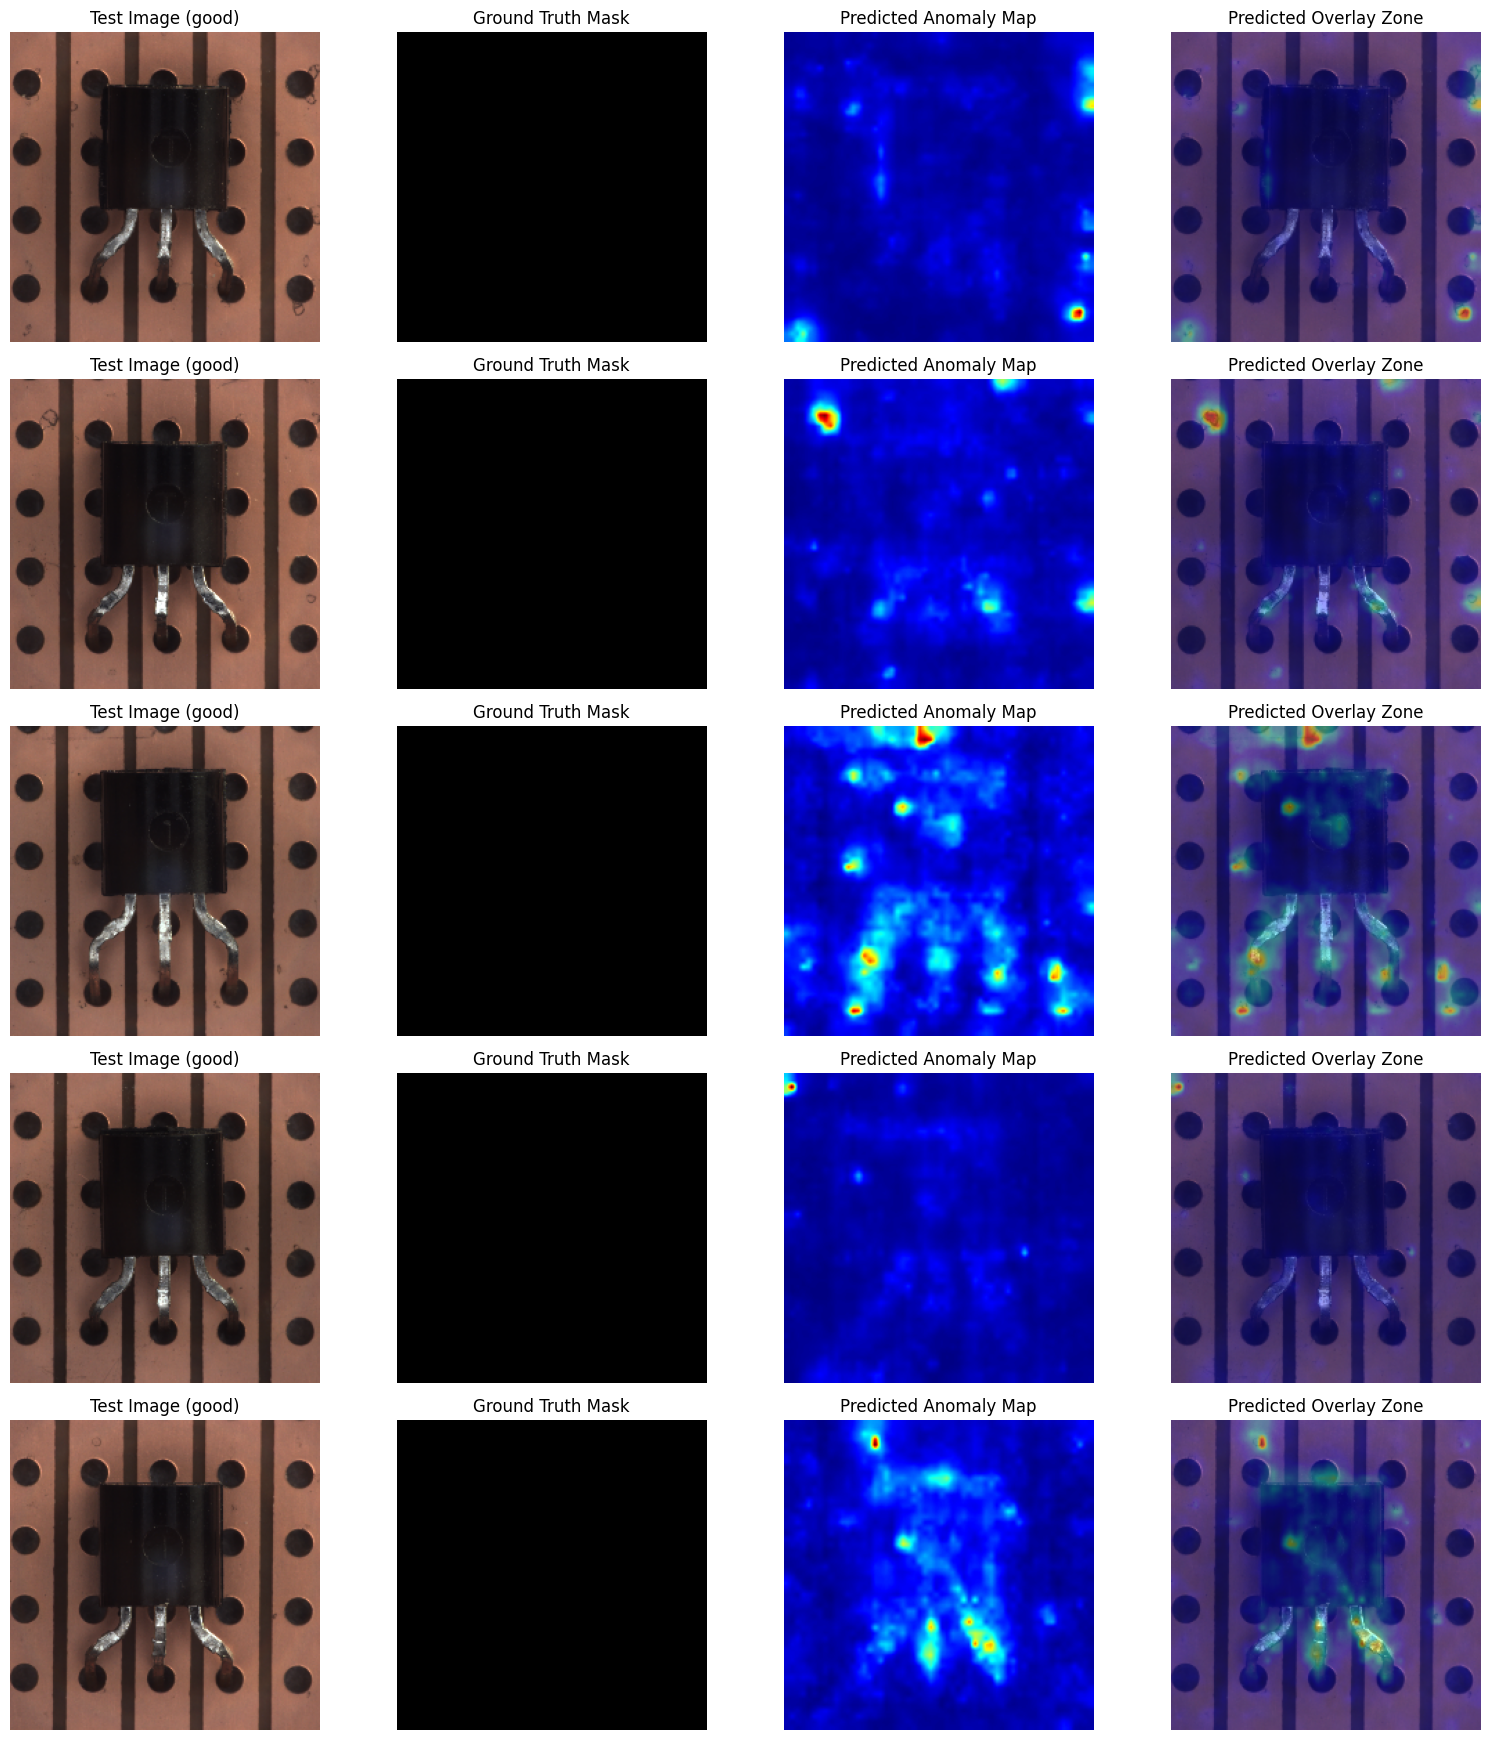

In [18]:
# Chọn 5 mẫu lỗi khác nhau từ tập test để hiển thị
num_samples = 5
indices = np.random.choice(len(test_dataset), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 4, figsize=(16, 3.5 * num_samples))

for idx, sample_idx in enumerate(indices):
    # Lấy dữ liệu từ test_dataset (chưa bị normalize để hiển thị ảnh đẹp)
    img_path = test_dataset.image_paths[sample_idx]
    category = test_dataset.categories[sample_idx]

    orig_img = cv2.imread(str(img_path))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_img = cv2.resize(orig_img, (224, 224))

    mask_gt = gt_masks[sample_idx]
    score_map = score_maps[sample_idx]

    # Chuẩn hóa score_map về dải [0, 255] để làm Heatmap
    norm_score_map = (score_map - score_map.min()) / (
        score_map.max() - score_map.min() + 1e-8
    )
    heatmap = (norm_score_map * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Blend Heatmap lên ảnh gốc
    overlay_pred = cv2.addWeighted(orig_img, 0.6, heatmap_color, 0.4, 0)

    # 1. Ảnh gốc
    axes[idx, 0].imshow(orig_img)
    axes[idx, 0].set_title(f"Test Image ({category})")
    axes[idx, 0].axis("off")

    # 2. Ground Truth Mask
    axes[idx, 1].imshow(mask_gt, cmap="gray")
    axes[idx, 1].set_title("Ground Truth Mask")
    axes[idx, 1].axis("off")

    # 3. Anomaly Heatmap
    axes[idx, 2].imshow(heatmap_color)
    axes[idx, 2].set_title("Predicted Anomaly Map")
    axes[idx, 2].axis("off")

    # 4. Overlay Prediction
    axes[idx, 3].imshow(overlay_pred)
    axes[idx, 3].set_title("Predicted Overlay Zone")
    axes[idx, 3].axis("off")

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report, f1_score, precision_recall_curve

# 1. Tìm Threshold tối ưu bằng Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(
    gt_labels, image_scores
)
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🎯 Ngưỡng phân loại tối ưu (Best Threshold): {best_threshold:.4f}")
print(f"🎯 Max Image-level F1-Score: {best_f1 * 100:.2f}%\n")

# 2. Đánh giá chi tiết Precision, Recall, F1-Score theo ngưỡng vừa tìm được
predictions = (image_scores >= best_threshold).astype(int)
print("=== BÁO CÁO ĐÁNH GIÁ PHÂN LOẠI (CLASSIFICATION REPORT) ===")
print(
    classification_report(
        gt_labels, predictions, target_names=["Good (0)", "Anomaly (1)"]
    )
)

🎯 Ngưỡng phân loại tối ưu (Best Threshold): 385.3498
🎯 Max Image-level F1-Score: 75.00%

=== BÁO CÁO ĐÁNH GIÁ PHÂN LOẠI (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

    Good (0)       0.83      0.83      0.83        60
 Anomaly (1)       0.75      0.75      0.75        40

    accuracy                           0.80       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.80      0.80      0.80       100



📊 Anomaly Score: 252.7082 | Threshold: 385.3498
🏷️  Kết quả kiểm tra: PASS (GOOD)


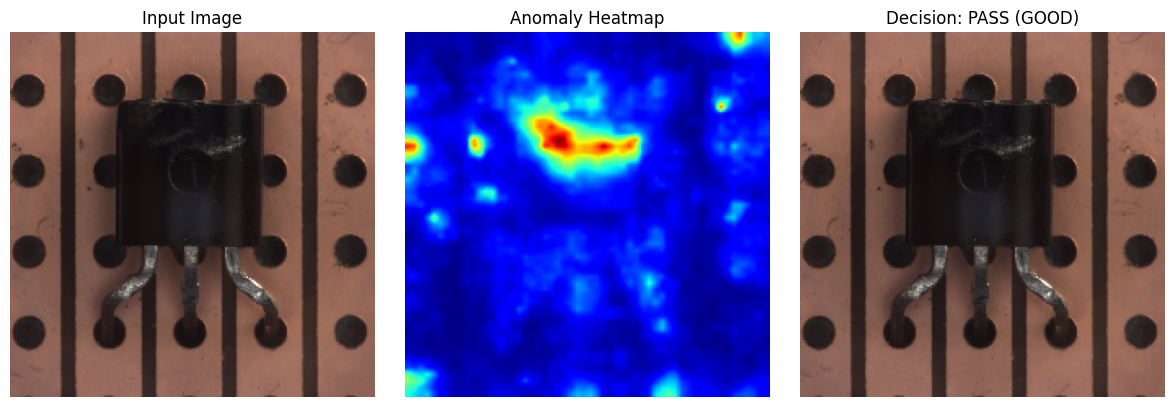

In [21]:
def inspect_transistor_image(model, img_path, threshold, device=None):
    """Hàm kiểm tra 1 sản phẩm transistor mới truyền vào."""
    # Tự động chọn device nếu không truyền vào
    if device is None:
        device = getattr(model, "device", "cpu")

    # 1. Read & Preprocess ảnh đầu vào
    orig_img = cv2.imread(str(img_path))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(orig_img, (224, 224))

    # Chuyển đổi sang Tensor theo chuẩn ImageNet
    tensor_img = test_transform(Image.fromarray(resized_img)).unsqueeze(0)

    # 2. Predict Anomaly Score & Map
    model.backbone.eval()
    with torch.no_grad():
        tensor_img = tensor_img.to(device)
        feats = model.extract_features(tensor_img)[:, model.idx, :, :].cpu()

        N = feats.shape[0]
        feats = feats.view(N, 100, model.H * model.W)

        dist_list = []
        for i in range(model.H * model.W):
            delta = feats[:, :, i] - model.mean[:, i]
            dist = torch.sum((delta @ model.cov_inv[i]) * delta, dim=1)
            dist_list.append(dist)

        dist_matrix = torch.stack(dist_list, dim=1).view(N, 1, model.H, model.W)
        anomaly_map = (
            torch.nn.functional.interpolate(
                dist_matrix, size=(224, 224), mode="bilinear", align_corners=False
            )
            .squeeze()
            .numpy()
        )

    # Image-level score
    image_score = anomaly_map.max()

    # 3. Ra quyết định dựa trên Threshold
    is_defect = image_score >= threshold
    status = "REJECT (DEFECT)" if is_defect else "PASS (GOOD)"
    color = (255, 0, 0) if is_defect else (0, 255, 0)

    # 4. Tạo Binary Mask khoanh vùng lỗi nét
    binary_mask = (anomaly_map >= threshold).astype(np.uint8) * 255

    # Trụ tạo Bounding Box/Contour quanh vết lỗi trên ảnh gốc
    contours, _ = cv2.findContours(
        binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    result_img = resized_img.copy()
    cv2.drawContours(result_img, contours, -1, color, 2)

    # 5. Hiển thị kết quả
    print(f"📊 Anomaly Score: {image_score:.4f} | Threshold: {threshold:.4f}")
    print(f"🏷️  Kết quả kiểm tra: {status}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(resized_img)
    axes[0].set_title("Input Image")
    axes[0].axis("off")

    axes[1].imshow(anomaly_map, cmap="jet")
    axes[1].set_title("Anomaly Heatmap")
    axes[1].axis("off")

    axes[2].imshow(result_img)
    axes[2].set_title(f"Decision: {status}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


# Chạy thử nghiệm lại với 1 ảnh test bất kỳ
sample_test_img = test_dataset.image_paths[25]
inspect_transistor_image(model, sample_test_img, best_threshold)

In [22]:
# Lưu trọng số PaDiM & Threshold ra file
checkpoint = {
    "threshold": best_threshold,
    "mean": model.mean,
    "cov_inv": model.cov_inv,
    "idx": model.idx,
    "H": model.H,
    "W": model.W,
}
torch.save(checkpoint, "padim_transistor_model.pth")
print("💾 Đã lưu model checkpoint thành công vào file 'padim_transistor_model.pth'")

💾 Đã lưu model checkpoint thành công vào file 'padim_transistor_model.pth'
